In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Selección de parámetros, validación y test

Muchos algoritmos tienen asociados algunos parámetros que influyen en la complejidad del modelo que pueden aprender. Recuerda cuando usamos `KNeighborsRegressor`. Si cambiamos el número de vecinos a considerar, obtenemos progresivamente predicciones más y más *suavizadas*:

<img src="figures/plot_kneigbors_regularization.png" width="100%">

En la figura anterior, podemos ver ajustes con tres valores diferentes para ``n_neighbors``. Con ``n_neighbors=2``, los datos se sobreajustan, el modelo es muy flexible y ajusta demasiado bien el ruido que hay presente en el dataset. Para ``n_neighbors=20``, el modelo no es suficientemente flexible y no puede ajustar la variación en los datos.

En la subfigura intermedia, hemos encontrado un buen punto intermedio, ``n_neighbors = 5``. Ajusta los datos bastante bien y no sufre ni de sobre-aprendizaje ni de infra-aprendizaje. Nos gustaría disponer de un método cuantitativo para identificar tanto el sobre-entrenamiento como el infra-entrenamiento y optimizar los hiperparámetros (en este caso, el número de vecinos) para llegar a los mejores resultados.

Intentamos obtener un equilibrio entre recordar particularidades (y ruido) de los datos de entrenamiento y modelar la suficiente variabilidad de los mismos. Este equilibrio necesita obtenerse para cualquier algoritmo de aprendizaje automático y es un concepto central, denominado equilibrio bias-varianza o "sobre-ajuste Vs. infra-ajuste"

<img src="figures/overfitting_underfitting_cartoon.svg" width="100%">


## Hiperparámetros, sobre-ajuste e infra-ajuste

Desafortunadamente, no hay un regla general para conseguir llegar a este punto óptimo y, por ello, el usuario debe encontrar el mejor equilibrio posible entre complejidad del modelo y generalización, probando distintas opciones para los hiper-parámetros. Los hiper-parámetros son aquellos parámetros que podemos ajustar sobre un algoritmos de aprendizaje automático (algoritmo que, a su vez, ajusta los parámetros del modelo en función de los datos de entrenamiento, de ahí el "hiper"). El número de vecinos $k$ del algoritmo kNN es un hiper-parámetro.

A menudo este ajuste de hiper-parámetros se hace mediante una búsqueda por fuerza bruta, por ejemplo usando varios valores de ``n_neighbors``:

In [9]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor
# Generamos un dataset sintético:
x = np.linspace(-3, 3, 100)
rng = np.random.RandomState(42)
y = np.sin(4 * x) + x + rng.normal(size=len(x))
X = x[:, np.newaxis]

cv = KFold(shuffle=True)

# Para cada parámetro, repetimos una validación cruzada
for n_neighbors in [1, 3, 5, 10, 20]:
    # cross_val_score realiza validación cruzada, reicibe un estimador, un dataset y un objeto que define la estrategia de validación cruzada
    scores = cross_val_score(KNeighborsRegressor(n_neighbors=n_neighbors), X, y, cv=cv)
    print(f'Scores por fold: ', scores)
    print("n_neighbors: %d, rendimiento medio: %f\n" % (n_neighbors, np.mean(scores)))

Scores por fold:  [0.55900048 0.56917223 0.40464633 0.5257576  0.47918255]
n_neighbors: 1, rendimiento medio: 0.507552

Scores por fold:  [0.72138607 0.65920935 0.60348361 0.65031246 0.7366146 ]
n_neighbors: 3, rendimiento medio: 0.674201

Scores por fold:  [0.81134249 0.61985924 0.76346372 0.72388533 0.77449557]
n_neighbors: 5, rendimiento medio: 0.738609

Scores por fold:  [0.77648617 0.73069861 0.81069744 0.54687168 0.85531289]
n_neighbors: 10, rendimiento medio: 0.744013

Scores por fold:  [0.71812522 0.57983237 0.63219206 0.67466964 0.44778041]
n_neighbors: 20, rendimiento medio: 0.610520



Hay una función en scikit-learn, llamada ``validation_plot``, que produce una figura similar a la que vimos previamente. Representa un parámetro, como el número de vecinos, enfrentado a los errores de entrenamiento y validación (utilizando validación cruzada):

Hay 5 folds y 6 valores de n_neighbors, por lo que hay 30 scores de entrenamiento y 30 scores de test:

[[1.         1.         1.         1.         1.        ]
 [0.8561923  0.84563051 0.82512025 0.88193271 0.90155215]
 [0.8308741  0.83231698 0.80583233 0.85419793 0.83820066]
 [0.80441285 0.80662035 0.79155338 0.82593784 0.82953415]
 [0.67896999 0.72113669 0.70223892 0.6986491  0.69450155]
 [0.5078747  0.53813715 0.53636147 0.5380321  0.55497788]] 

[[ 0.57895439  0.66628266  0.76286592  0.53305422 -0.42657827]
 [ 0.6976859   0.75850124  0.82748488  0.65001166  0.52086391]
 [ 0.76608495  0.73787229  0.81948536  0.69560629  0.63722075]
 [ 0.86303541  0.66134315  0.78629042  0.72015987  0.67077572]
 [ 0.81616769  0.55014582  0.6554052   0.67409274  0.59328909]
 [ 0.64136897  0.39895611  0.4260146   0.48127834  0.60854488]] 



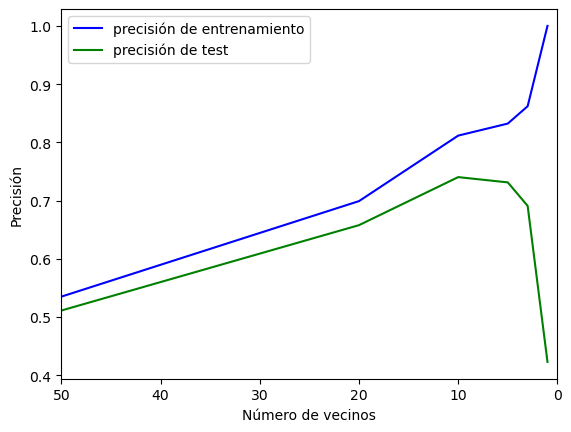

In [10]:
from sklearn.model_selection import validation_curve
n_neighbors = [1, 3, 5, 10, 20, 50]
train_scores, test_scores = validation_curve(KNeighborsRegressor(), X, y, param_name="n_neighbors",
                                             param_range=n_neighbors, cv=cv)

print("Hay 5 folds y 6 valores de n_neighbors, por lo que hay 30 scores de entrenamiento y 30 scores de test:\n")
print(train_scores, "\n")
print(test_scores, "\n")

plt.plot(n_neighbors, train_scores.mean(axis=1), 'b', label="precisión de entrenamiento")
plt.plot(n_neighbors, test_scores.mean(axis=1), 'g', label="precisión de test")
plt.ylabel('Precisión')
plt.xlabel('Número de vecinos')
plt.xlim([50, 0])
plt.legend(loc="best");

<div class="alert alert-warning">
    Observa que muchos vecinos resultan en un modelo suavizado o más simple, por lo que el eje X se ha dibujado invertido.
</div>

Si más de un parámetro es importante, como los parámetros ``C`` y ``gamma`` de una máquina de vectores soporte (SVM) (de las cuales hablaremos después), se intentan todas las posibles combinaciones de parámetros:

In [12]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVR

# Hacer validación cruzada (k-fold) para cada combinación de parámetros:
for C in [0.001, 0.01, 0.1, 1, 10]:
    for gamma in [0.001, 0.01, 0.1, 1]:
        scores = cross_val_score(SVR(C=C, gamma=gamma), X, y, cv=cv)
        print(f'Scores por fold: ', scores)
        print("C: %f, gamma: %f, valor medio de R^2: %f\n" % (C, gamma, np.mean(scores)))

Scores por fold:  [-0.72572915 -0.01401764 -0.43772918 -0.0760195  -0.00224039]
C: 0.001000, gamma: 0.001000, valor medio de R^2: -0.251147

Scores por fold:  [-0.00545321  0.00282475 -0.00455992 -0.03945833 -0.06589389]
C: 0.001000, gamma: 0.010000, valor medio de R^2: -0.022508

Scores por fold:  [ 0.00948918 -0.12920947  0.01132653 -0.05992664  0.0006387 ]
C: 0.001000, gamma: 0.100000, valor medio de R^2: -0.033536

Scores por fold:  [ 0.0089318  -0.01665534 -0.00204924  0.00054151 -0.06537414]
C: 0.001000, gamma: 1.000000, valor medio de R^2: -0.014921

Scores por fold:  [-0.01047268  0.0011974  -0.01558736 -0.00627205 -0.00193413]
C: 0.010000, gamma: 0.001000, valor medio de R^2: -0.006614

Scores por fold:  [-0.05917166  0.023653    0.02763198 -0.10478607  0.02315354]
C: 0.010000, gamma: 0.010000, valor medio de R^2: -0.017904

Scores por fold:  [ 0.05040755  0.07109441 -0.09220758  0.06834443  0.04270146]
C: 0.010000, gamma: 0.100000, valor medio de R^2: 0.028068

Scores por fol

Como esto es algo que se hace frecuentemente en aprendizaje automático, hay una clase ya implementada en scikit-learn, ``GridSearchCV``. ``GridSearchCV`` utiliza un diccionario que describe los parámetros que deberían probarse y un modelo que entrenar.

La rejilla de parámetros se define como un diccionario, donde las claves son los parámetros y los valores son las cantidades a probar.

In [18]:
from sklearn.model_selection import GridSearchCV
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1, 1]}

"""
GridSearchCV no entrena modelos al crearse: solo define la búsqueda. Al llamar a grid.fit(X, y) se ejecuta la validación cruzada con todas las combinaciones del param_grid para elegir la mejor, y luego se vuelve a entrenar el estimador final con todos los datos usando esos hiperparámetros. Sin fit, no hay modelos entrenados ni best_params_.

OJO: El modelo final entrenado con los mejores parámetros se construye usando TODOS LOS DATOS, es decir, sin hacer folds. Por tanto, no se puede usar el rendimiento de ese modelo final como estimación del rendimiento real, ya que se ha entrenado con todos los datos. Para estimar el rendimiento real, habría que hacer una validación cruzada externa (nested cross-validation) o usar un conjunto de test independiente.

Esto se explica un poco más adelante de este mismo cuaderno de jupyter.
"""

grid = GridSearchCV(SVR(), param_grid=param_grid, cv=cv, verbose=3)
print("Tipo de la variable grid:", type(grid))

Tipo de la variable grid: <class 'sklearn.model_selection._search.GridSearchCV'>


Una de las cosas interesantes de GridSearchCV es que es un *meta-estimador*. Utiliza un estimador como SVR y crea un nuevo estimador que se comporta exactamente igual que SVR, por lo que podemos llamar a ``fit`` para entrenarlo:

In [19]:
grid.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END .............C=0.001, gamma=0.001;, score=-0.001 total time=   0.0s
[CV 2/5] END .............C=0.001, gamma=0.001;, score=-0.205 total time=   0.0s
[CV 3/5] END .............C=0.001, gamma=0.001;, score=-0.218 total time=   0.0s
[CV 4/5] END .............C=0.001, gamma=0.001;, score=-0.014 total time=   0.0s
[CV 5/5] END ..............C=0.001, gamma=0.001;, score=0.000 total time=   0.0s
[CV 1/5] END ...............C=0.001, gamma=0.01;, score=0.002 total time=   0.0s
[CV 2/5] END ..............C=0.001, gamma=0.01;, score=-0.203 total time=   0.0s
[CV 3/5] END ..............C=0.001, gamma=0.01;, score=-0.216 total time=   0.0s
[CV 4/5] END ..............C=0.001, gamma=0.01;, score=-0.012 total time=   0.0s
[CV 5/5] END ...............C=0.001, gamma=0.01;, score=0.003 total time=   0.0s
[CV 1/5] END ................C=0.001, gamma=0.1;, score=0.012 total time=   0.0s
[CV 2/5] END ...............C=0.001, gamma=0.1;

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'gamma': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3

``GridSearchCV`` aplica un proceso algo más complejo que el visto anteriormente. Primero, ejecuta el mismo bucle de validación cruzada para encontrar la mejor combinación de parámetros. Una vez tiene la mejor combinación, ejecuta el método ``fit`` de nuevo sobre todos los datos que se le pasan (sin validación cruzada), para construir un nuevo modelo con los parámetros óptimos obtenidos anteriormente.

Después, utilizando los métodos ``predict`` o ``score`` podemos realizar una nueva predicción:


In [20]:
grid.predict(X)

array([-1.79762875, -1.74054091, -1.71412904, -1.72272347, -1.76880247,
       -1.8527208 , -1.97255382, -2.12407501, -2.30087676, -2.49463429,
       -2.695503  , -2.89262935, -3.07474705, -3.23082299, -3.35071314,
       -3.42578612, -3.44947391, -3.41771237, -3.32924127, -3.18574205,
       -2.9918017 , -2.75470244, -2.48404785, -2.19124658, -1.88888388,
       -1.59001819, -1.30744475, -1.05297034, -0.8367425 , -0.66667333,
       -0.54799235, -0.4829551 , -0.4707249 , -0.50743515, -0.58642852,
       -0.69865919, -0.83323456, -0.97806438, -1.12057877, -1.24847261,
       -1.35043139, -1.41679516, -1.44012026, -1.41560488, -1.3413525 ,
       -1.21845724, -1.05090633, -0.84530623, -0.61045003, -0.35675398,
       -0.09559933,  0.16137852,  0.40300817,  0.61926205,  0.80185531,
        0.94472644,  1.04437082,  1.10000798,  1.11357463,  1.08954695,
        1.03460678,  0.95717608,  0.86685224,  0.7737823 ,  0.68801751,
        0.61888941,  0.57444669,  0.56098656,  0.58270777,  0.64

Puedes observar los mejores parámetros obtenidos por ``GridSearchCV`` en su atributo ``best_params_`` y la puntuación correspondiente en su atributo ``best_score_``:

In [21]:
print(grid.best_score_)

0.763547352864644


In [22]:
print(grid.best_params_)

{'C': 10, 'gamma': 1}


Pero puedes investigar más a fondo el rendimiento y algunas cosas más sobre cada una de las combinaciones de parámetros accediendo al atributo `cv_results_`. `cv_results_` es un diccionario donde cada clave es una cadena y cada valor un array. Se puede por tanto usar para crear un ``DataFrame`` de pandas.

In [23]:
type(grid.cv_results_)

dict

In [24]:
print(grid.cv_results_.keys())

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_C', 'param_gamma', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])


In [31]:
import pandas as pd

# Obtenemos un Dataframe, pero esta vez en vez de representar a un dataset, representa una tabla con los resultados de la validación cruzada para cada combinación de hiperparámetros probada en la búsqueda en cuadrícula.
cv_results = pd.DataFrame(grid.cv_results_)
print(cv_results.shape)
print("Para cada combinación de parámetros (20 combinaciones en total), estos son los resultados usando los 5 folds:\n")
cv_results.head()


(20, 15)
Para cada combinación de parámetros (20 combinaciones en total), estos son los resultados usando los 5 folds:



,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000627,0.000107,0.000405,0.000042,0.001,0.001,"{'C': 0.001, 'gamma': 0.001}",-0.000584,-0.205216,-0.217824,-0.014341,0.000281,-0.087537,0.101443,20
1,0.000932,0.000289,0.000529,0.000136,0.001,0.010,"{'C': 0.001, 'gamma': 0.01}",0.001755,-0.202650,-0.215603,-0.011903,0.002940,-0.085092,0.101490,19
2,0.000587,0.000097,0.000378,0.000046,0.001,0.100,"{'C': 0.001, 'gamma': 0.1}",0.011637,-0.191836,-0.206163,-0.001020,0.014670,-0.074542,0.101856,16
3,0.000621,0.000199,0.000418,0.000099,0.001,1.000,"{'C': 0.001, 'gamma': 1}",0.010160,-0.193204,-0.208482,-0.002757,0.013065,-0.076244,0.101989,17
4,0.000540,0.000082,0.000476,0.000192,0.010,0.001,"{'C': 0.01, 'gamma': 0.001}",0.001997,-0.202381,-0.215369,-0.011662,0.003208,-0.084842,0.101491,18


In [32]:
cv_results_tiny = cv_results[['param_C', 'param_gamma', 'mean_test_score']]
print(cv_results_tiny.shape)
cv_results_tiny.sort_values(by='mean_test_score', ascending=False).head()

(20, 3)


,param_C,param_gamma,mean_test_score
19,10.0,1.00,0.763547
15,1.0,1.00,0.721800
14,1.0,0.10,0.662517
18,10.0,0.10,0.660061
17,10.0,0.01,0.608570


Sin embargo, hay un problema en la utilización de este rendimiento para la evaluación. Puedes estar incurriendo en lo que se denomina un error de probar varias hipótesis. Si tienes muchas combinaciones de parámetros, algunas de ellas puede ser que funcionen mejor solo por aleatoriedad y que el rendimiento que estás obteniendo no sea el mismo cuando tengamos nuevos datos. Por tanto, es en general buena idea realizar una separación en entrenamiento y test previa a la búsqueda *grid*. Este patrón se suele denominar partición de entrenamiento, test y validación, y es bastante común en aprendizaje automático:

<img src="figures/grid_search_cross_validation.svg" width="100%">

Podemos emular este proceso fácilmente dividiendo primero los datos con ``train_test_split``, aplicando ``GridSearchCV`` al conjunto de entrenamiento, y calculando el ``score`` correspondiente solo con el conjunto de test:

In [34]:
from sklearn.model_selection import train_test_split

# SVR es un método de regresión, por lo tanto no hacemos una partición estratificada, en todo caso podemos hacer una partición aleatoria simple con train_test_split usando el paramámetro random_state para asegurar la reproducibilidad y shuffle=True por defecto
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1) # shuffle=True esta por defecto

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1, 1]}
cv = KFold(n_splits=10, shuffle=True)

grid = GridSearchCV(SVR(), param_grid=param_grid, cv=cv, verbose=3)

grid.fit(X_train, y_train)

grid.score(X_test, y_test)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END ............C=0.001, gamma=0.001;, score=-0.018 total time=   0.0s
[CV 2/10] END ............C=0.001, gamma=0.001;, score=-0.026 total time=   0.0s
[CV 3/10] END ............C=0.001, gamma=0.001;, score=-0.036 total time=   0.0s
[CV 4/10] END ............C=0.001, gamma=0.001;, score=-0.230 total time=   0.0s
[CV 5/10] END ............C=0.001, gamma=0.001;, score=-0.539 total time=   0.0s
[CV 6/10] END ............C=0.001, gamma=0.001;, score=-0.817 total time=   0.0s
[CV 7/10] END ............C=0.001, gamma=0.001;, score=-0.031 total time=   0.0s
[CV 8/10] END ............C=0.001, gamma=0.001;, score=-0.003 total time=   0.0s
[CV 9/10] END ............C=0.001, gamma=0.001;, score=-0.185 total time=   0.0s
[CV 10/10] END ...........C=0.001, gamma=0.001;, score=-0.274 total time=   0.0s
[CV 1/10] END .............C=0.001, gamma=0.01;, score=-0.016 total time=   0.0s
[CV 2/10] END .............C=0.001, gamma=0.01

0.7262035177984737

Podemos comprobar de nuevo los parámetros obtenidos con:

In [35]:
grid.best_params_

{'C': 10, 'gamma': 1}

A veces se utiliza un esquema más simple, que parte los datos en tres subconjuntos entrenamiento, validación y test. Esto es una alternativa si tu conjunto de datos es muy grande o si es imposible entrenar muchos modelos mediante validación cruzada, porque entrenar cada modelo es muy costoso computacionalmente. Para hacer este tipo de partición tendríamos que hacer una partición con ``train_test_split`` y después aplicar ``GridSearchCV`` con un ``ShuffleSplit`` y una sola iteración:

<img src="figures/train_validation_test2.svg" width="100%">

In [36]:
from sklearn.model_selection import train_test_split, ShuffleSplit

# shuffle=True esta por defecto
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10], 'gamma': [0.001, 0.01, 0.1, 1]}

# En vez de cv = KFold(n_splits=10, shuffle=True), usamos una única partición aleatoria
single_split_cv = ShuffleSplit(n_splits=1) 

grid = GridSearchCV(SVR(), param_grid=param_grid, cv=single_split_cv, verbose=3)

grid.fit(X_train, y_train)
grid.score(X_test, y_test)

Fitting 1 folds for each of 20 candidates, totalling 20 fits
[CV 1/1] END .............C=0.001, gamma=0.001;, score=-0.152 total time=   0.0s
[CV 1/1] END ..............C=0.001, gamma=0.01;, score=-0.149 total time=   0.0s
[CV 1/1] END ...............C=0.001, gamma=0.1;, score=-0.138 total time=   0.0s
[CV 1/1] END .................C=0.001, gamma=1;, score=-0.141 total time=   0.0s
[CV 1/1] END ..............C=0.01, gamma=0.001;, score=-0.149 total time=   0.0s
[CV 1/1] END ...............C=0.01, gamma=0.01;, score=-0.126 total time=   0.0s
[CV 1/1] END ................C=0.01, gamma=0.1;, score=-0.049 total time=   0.0s
[CV 1/1] END ..................C=0.01, gamma=1;, score=-0.050 total time=   0.0s
[CV 1/1] END ...............C=0.1, gamma=0.001;, score=-0.124 total time=   0.0s
[CV 1/1] END .................C=0.1, gamma=0.01;, score=0.066 total time=   0.0s
[CV 1/1] END ..................C=0.1, gamma=0.1;, score=0.570 total time=   0.0s
[CV 1/1] END ....................C=0.1, gamma=1;

0.6414905235299841

Esto es mucho más rápido pero puede resultar en valores peores de los hiper-parámetros y, por tanto, peores resultados.

In [37]:
clf = GridSearchCV(SVR(), param_grid=param_grid)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.7262035177984737

<div class="alert alert-success">
    <b>EJERCICIO</b>:
     <ul>
      <li>
      Aplica una búsqueda *grid* para encontrar el mejor valor del parámetro número de vecinos para el ``KNeighborsClassifier`` para el dataset de ``digits``.
      </li>
    </ul>
</div>

In [47]:
from sklearn.datasets import load_digits

digits = load_digits()

print(digits.data.shape)
print(digits.target_names)


(1797, 64)
[0 1 2 3 4 5 6 7 8 9]


In [61]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=1) # shuffle=True esta por defecto

param_grid = {'n_neighbors': [1, 3, 5, 10], 'p': [1, 2]}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, cv=cv, verbose=1)

grid.fit(X_train, y_train)

etiquetas_test_predichas = grid.predict(X_test)

grid.score(X_test, y_test)

valor = np.mean(etiquetas_test_predichas == y_test)

print(f'Best score: {grid.best_score_}')
print(f'Accuracy en test (esto no seria un valor medio): {valor}')
print(f'Best parameters: {grid.best_params_}')


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best score: 0.9836513837257332
Accuracy en test (esto no seria un valor medio): 0.9888888888888889
Best parameters: {'n_neighbors': 1, 'p': 2}
